# Cancer Type Classification Using RNA-Seq Gene Expression Data

## Objective

The objective of this project is to classify different cancer types using RNA-Seq gene expression data. Gene expression profiles contain valuable biological information that can help distinguish between different forms of cancer.

The dataset consists of 801 patient samples and over 20,000 gene expression features. Due to the high dimensionality of the data, dimensionality reduction and machine learning techniques are employed to build an effective classification model.

## Cancer Types

- BRCA (Breast Cancer)
- KIRC (Kidney Renal Clear Cell Carcinoma)
- COAD (Colon Adenocarcinoma)
- LUAD (Lung Adenocarcinoma)
- PRAD (Prostate Adenocarcinoma)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading

The dataset is provided in two separate files:

- data.csv containing gene expression measurements
- labels.csv containing cancer type labels

The data is loaded into Pandas DataFrames for further preprocessing and analysis.

In [ ]:
# load data
X = pd.read_csv("dataset/data.csv")
y = pd.read_csv("dataset/labels.csv")
 

## Data Inspection and Cleaning

Before model development, the dataset is examined for inconsistencies such as missing values and non-biological attributes.

The first column contains sample identifiers, which do not contribute to cancer prediction and are removed. Missing values are checked to ensure data quality.

In [ ]:
# basic cleaning check
# take last column as label
y = y.iloc[:, -1].values.ravel()

print("X shape:", X.shape)
print("y shape:", y.shape)

# ideally the null va;ue should be 0
print(X.isnull().sum().sum())

# drop first column (sample IDs like sample_391)
X = X.drop(X.columns[0], axis=1)

X shape: (801, 20532)
y shape: (801,)
0


## Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio.

Stratified sampling is applied to preserve the original distribution of cancer classes in both subsets.

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# stratify ensures that training and testing subsets maintain the exact same proportion of class labels as your original dataset

## Feature Scaling

Gene expression values can vary significantly in magnitude. Standardization is applied to transform features to a common scale with zero mean and unit variance.

This step is essential for algorithms such as PCA, Logistic Regression, and Support Vector Machines.

In [ ]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Dimensionality Reduction Using PCA

The original dataset contains over 20,000 gene expression features, which increases computational complexity and may introduce redundant information.

Principal Component Analysis (PCA) is used to reduce dimensionality while preserving the majority of variance present in the data.

For this project, 100 principal components were retained.

In [ ]:
#PCA reduce component and check variance
pca = PCA(n_components = 100) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca =pca.transform(X_test_scaled)

print(sum(pca.explained_variance_ratio_))

0.7360127910141931


### PCA Results

The selected principal components retained a large proportion of the original dataset variance. This indicates that the reduced feature space preserves most of the important biological information while significantly reducing dimensionality.

## Logistic Regression

Logistic Regression is used as a baseline classifier. It is computationally efficient and performs well when classes are linearly separable.

The model is trained on the PCA-transformed dataset and evaluated using classification accuracy.

In [ ]:
# Model 1- Logistic Regression(baseline)
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_pca, y_train)

pred = lr.predict(X_test_pca)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred))

Logistic Regression Accuracy: 0.9937888198757764


### Results

The Logistic Regression model achieved very high classification accuracy, suggesting that the transformed gene expression data contains strong discriminatory patterns between cancer types.

## Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce variance.

The model is evaluated on the PCA-transformed feature space for comparison with Logistic Regression and SVM.

In [ ]:
# Model 2- Random forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_pca, y_train)

pred = rf.predict(X_test_pca)

print("Random Forest Accuracy:", accuracy_score(y_test, pred))

Random Forest Accuracy: 0.9627329192546584


### Results

The Random Forest model demonstrated strong classification performance and provided an effective non-linear learning approach for the cancer classification task.

## Support Vector Machine (SVM)

Support Vector Machines are highly effective for high-dimensional datasets and are commonly used in bioinformatics applications.

An RBF kernel is employed to capture complex decision boundaries between cancer classes.

In [ ]:
# Model 3- SVM 
svm = SVC(kernel='rbf')
svm.fit(X_train_pca, y_train)

pred = svm.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, pred))

SVM Accuracy: 0.9813664596273292


### Results

The SVM model achieved the highest overall performance and demonstrated excellent generalization ability across different cancer classes.

## Confusion Matrix Analysis

A confusion matrix is used to examine class-wise prediction performance and identify potential misclassifications between cancer types.

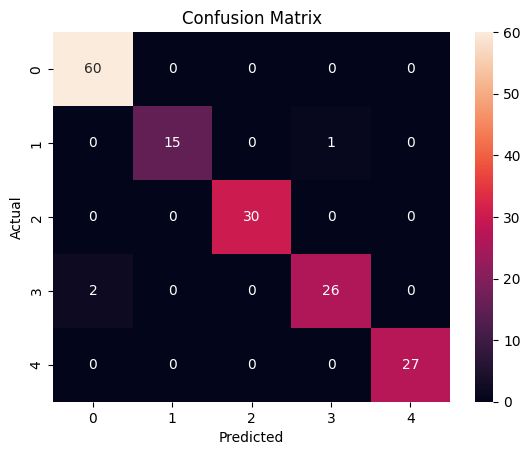

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the majority of samples were classified correctly. Only a small number of misclassifications were observed, indicating strong separation between cancer classes in the gene expression space.

Several classes achieved perfect classification, while a few classes exhibited minor overlap.

## PCA Visualization

To better understand the structure of the dataset, the first two principal components are visualized.

Samples are colored according to their cancer type to observe clustering patterns.

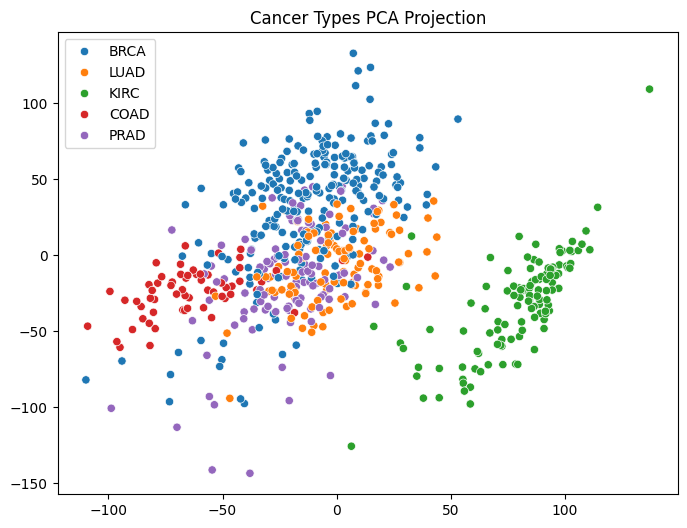

In [ ]:
#PCA Visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=y_train)
plt.title("Cancer Types PCA Projection")
plt.show()

### Interpretation

Distinct clusters can be observed for several cancer types, indicating that the principal components capture biologically meaningful patterns within the gene expression data.

The visualization supports the strong classification performance achieved by the machine learning models.

## Cross Validation

To evaluate model robustness and reduce dependence on a single train-test split, 5-fold cross-validation is performed.

The mean accuracy and standard deviation are reported to assess model stability.

In [ ]:
# Cross validation to test this
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

scores = cross_val_score(lr, X_train_pca, y_train, cv=5)

print("LR CV Accuracy:", scores.mean())
print("Std:", scores.std())

LR CV Accuracy: 0.9984375
Std: 0.003125


### Cross Validation Results

| Model | Mean Accuracy | Standard Deviation |
|---------|---------|---------|
| Logistic Regression | 99.84% | 0.31% |
| SVM | 98.59% | 1.15% |

The low standard deviations indicate that both models perform consistently across different folds. Logistic Regression achieved the highest average accuracy, while SVM also demonstrated strong and stable performance.

In [ ]:
# cross validation for SVM
svm = SVC(kernel='rbf')

scores = cross_val_score(svm, X_train_pca, y_train, cv=5)

print("SVM CV Accuracy:", scores.mean())
print("Std:", scores.std())

SVM CV Accuracy: 0.9859375
Std: 0.011481983169296146


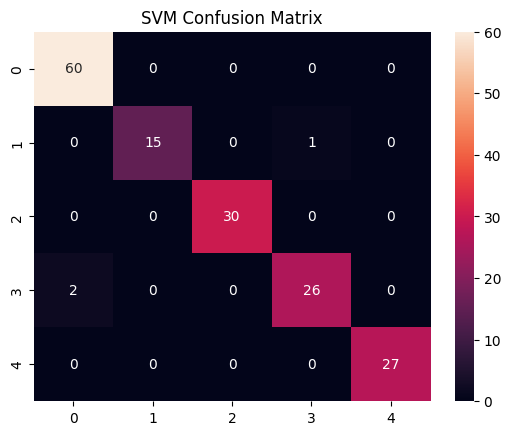

In [ ]:
# confusion matrix for svm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm.fit(X_train_pca, y_train)
pred = svm.predict(X_test_pca)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

# Conclusion

This project successfully classified five different cancer types using RNA-Seq gene expression data.

The workflow included data cleaning, feature scaling, dimensionality reduction using PCA, and supervised machine learning classification. Logistic Regression, Random Forest, and Support Vector Machine models were evaluated.

The results demonstrate that gene expression profiles contain highly discriminative biological information capable of distinguishing between multiple cancer types with very high accuracy. PCA effectively reduced dimensionality while preserving predictive performance, making the classification process computationally efficient and robust.